In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils import resample

import xgboost as xgb

from scipy.stats import randint, uniform

import os
import joblib

XG Boositng Model. 
We use CATASTROPHIC as our dependent variable now. And we are using the transformed dataset with the vegetation dummies. 

In [44]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv') 
df.head()

,index,latitude,longitude,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,...,month_sin,month_cos,Vegetation_0,Vegetation_4,Vegetation_9,Vegetation_12,Vegetation_14,Vegetation_15,Vegetation_16,Vegetation
0,0,18.105072,-66.753044,24.480974,24.716923,24.902597,4.341807,3.492857,3.262092,78.216590,...,8.660254e-01,0.500000,False,False,False,True,False,False,False,Open Shrubland
1,1,35.038330,-87.610000,7.553433,7.010000,0.343529,2.709764,2.881707,1.976471,70.840000,...,-2.449294e-16,1.000000,False,False,False,False,False,True,False,Polar Desert/Rock/Ice
2,2,34.947800,-88.722500,4.971930,5.782766,5.558750,3.364499,2.923830,2.695833,75.531629,...,8.660254e-01,0.500000,False,False,False,False,False,False,True,Secondary Tropical Evergreen Broadleaf Forest
3,3,39.641400,-119.308300,16.275967,18.996181,18.142564,4.054982,3.398329,3.671282,44.778429,...,1.224647e-16,-1.000000,True,False,False,False,False,False,False,Unknown
4,4,31.316978,-83.393649,14.877341,16.409326,17.175319,2.000214,1.727202,1.590696,79.896679,...,5.000000e-01,0.866025,False,False,False,True,False,False,False,Open Shrubland


Using Categorical Vegetation Variable instead of dummies 

In [45]:
dummy_cols = [col for col in df.columns if col.startswith('Vegetation_')]

df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv').drop(columns=dummy_cols)

df.head()

,index,latitude,longitude,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic,month_sin,month_cos,Vegetation
0,0,18.105072,-66.753044,24.480974,24.716923,24.902597,4.341807,3.492857,3.262092,78.216590,76.793750,76.381579,0.0,0.0,0.0,0.017923,1,8.660254e-01,0.500000,Open Shrubland
1,1,35.038330,-87.610000,7.553433,7.010000,0.343529,2.709764,2.881707,1.976471,70.840000,65.858911,55.505882,59.8,8.4,0.0,0.184355,0,-2.449294e-16,1.000000,Polar Desert/Rock/Ice
2,2,34.947800,-88.722500,4.971930,5.782766,5.558750,3.364499,2.923830,2.695833,75.531629,75.868613,76.812834,168.8,42.2,18.1,0.194544,1,8.660254e-01,0.500000,Secondary Tropical Evergreen Broadleaf Forest
3,3,39.641400,-119.308300,16.275967,18.996181,18.142564,4.054982,3.398329,3.671282,44.778429,37.140811,35.353846,10.4,7.2,0.0,0.487447,0,1.224647e-16,-1.000000,Unknown
4,4,31.316978,-83.393649,14.877341,16.409326,17.175319,2.000214,1.727202,1.590696,79.896679,73.431818,70.199388,26.0,0.0,0.0,0.148904,0,5.000000e-01,0.866025,Open Shrubland


In [46]:
X = df.drop(['catastrophic','index'], axis=1)
y = df['catastrophic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

NOW WE WANT TO FOCUS MORE ON RECALL RATHER THAN ACCURACY, SO I INCORPORATE IT IN THE GRID SEARCH


STEP 1: RANDOMIZED GRID SEARCH FOR HYPERPARAMETERS, FOCUSING ON RECALL AS MY SCORING PARAMETER


In [47]:
XGBoost = xgb.XGBClassifier(enable_categorical=True, tree_method='hist')

# Define param distributions for RSCV
param_dist = {
    'n_estimators': randint(100, 300),     
    'max_depth': [4, 5 ,6, 8, 10],
    "learning_rate": [0.05, 0.1],
    "colsample_bytree": [0.5, 0.75],
    'min_child_weight': [4, 5, 6], # after a lot of tries the opimal was 5, so now I use a different range (before randit(1, 10))
    'gamma': uniform(4.5 , 3), # increasing the gamma does significantly improve recall rate with slight reduction in accuracy
    'scale_pos_weight': [1.8 , 2, 2.2] # scaling the number of catastrophic fires to normal fires can be useful in ballancing predictions, I will use 1 (neutral), 1.8 (appr. the ratio) and 2
}



# Randomized Search setup
random_search = RandomizedSearchCV(
    estimator=XGBoost,
    param_distributions=param_dist,
    n_iter=100,                 # relative high number due to fast processing from XGBoost
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='recall',  # Focus on Recall instead of accuracy
    random_state=42
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.1s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.1s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.0s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.1s
[CV] END colsample_bytree=0.75, gamma=4.967983561008608, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=199, scale_pos_weight=2.2; total time=   0.0s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_chi

ValueError: 
All the 500 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/leonkriesmair/Repos/BigDataProject/.venv/lib/python3.13/site-packages/xgboost/data.py", line 407, in pandas_feature_info
    new_feature_types.append(_pandas_dtype_mapper[dtype.name])
                             ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'object'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/leonkriesmair/Repos/BigDataProject/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

Best Model according RSCV

In [ ]:
best_model = random_search.best_estimator_
y_pred_recall = best_model.predict(X_test)
accuracy_recall = accuracy_score(y_test, y_pred_recall)
conf_matrix_recall = confusion_matrix(y_test, y_pred_recall)  
class_report_recall = classification_report(y_test, y_pred_recall)  

print("Accuracy:", accuracy_recall)
print("Confusion Matrix:\n", conf_matrix_recall)
print("Classification Report:", class_report_recall)

Accuracy: 0.6855683955925826
Confusion Matrix:
 [[3310 1555]
 [ 785 1792]]
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.68      0.74      4865
           1       0.54      0.70      0.60      2577

    accuracy                           0.69      7442
   macro avg       0.67      0.69      0.67      7442
weighted avg       0.71      0.69      0.69      7442



STEP 2: GRIDSEARCH IN THE OPTIMAL AREA, after updating the parameter grid

In [ ]:
# Using RandomizedSearch to first find area of interesting parameters
# and then using GridSearch to find the best parameters in that area

best_params = random_search.best_params_
param_grid_fine = {  
    'max_depth': [best_params['max_depth'] - 1, best_params['max_depth'], best_params['max_depth'] + 1],
    'learning_rate': [best_params['learning_rate'] - 0.02, best_params['learning_rate'], best_params['learning_rate'] + 0.02],
    'gamma': [best_params['gamma'] - 0.3, best_params['gamma'], best_params['gamma'] + 0.3],
    'n_estimators': [best_params['n_estimators']],
    'min_child_weight': [best_params['min_child_weight']],
    'colsample_bytree': [best_params['colsample_bytree']],
    'scale_pos_weight': [best_params['scale_pos_weight']],
}

grid_search_first = GridSearchCV(
    estimator=XGBoost,
    param_grid=param_grid_fine,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)
grid_search_first.fit(X_train, y_train)

print(grid_search_first.best_params_)
print(grid_search_first.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END colsample_bytree=0.75, gamma=5.885600076431321, learning_rate=0.08, max_depth=3, min_child_weight=6, n_estimators=112, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.75, gamma=5.885600076431321, learning_rate=0.08, max_depth=3, min_child_weight=6, n_estimators=112, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.75, gamma=5.885600076431321, learning_rate=0.08, max_depth=3, min_child_weight=6, n_estimators=112, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.75, gamma=5.885600076431321, learning_rate=0.08, max_depth=3, min_child_weight=6, n_estimators=112, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.75, gamma=5.885600076431321, learning_rate=0.08, max_depth=3, min_child_weight=6, n_estimators=112, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.75, gamma=5.885600076431321, learning_rate=0.08, max_depth=4, min

In [ ]:
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best recall score from RandomizedSearchCV:", random_search.best_score_)

print("Best parameters from GridSearchCV:", grid_search_first.best_params_)
print("Best recall score from GridSearchCV:", grid_search_first.best_score_)

Best parameters from RandomizedSearchCV: {'colsample_bytree': 0.75, 'gamma': np.float64(6.185600076431321), 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 6, 'n_estimators': 112, 'scale_pos_weight': 2.2}
Best recall score from RandomizedSearchCV: 0.675012130033964
Best parameters from GridSearchCV: {'colsample_bytree': 0.75, 'gamma': np.float64(5.885600076431321), 'learning_rate': 0.08, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 112, 'scale_pos_weight': 2.2}
Best recall score from GridSearchCV: 0.6779233381853469


STEP 3: IMPLEMENTATION OF OPTIMAL HYPERPARAMETERS IN XGBOOST MODEL

In [ ]:
xgb_model_final = grid_search_first.best_estimator_
xgb_model_final.fit(X_train, y_train)

y_pred_final = xgb_model_final.predict(X_test)
accuracy_final = accuracy_score(y_test, y_pred_final)
conf_matrix_final = confusion_matrix(y_test, y_pred_final)  
class_report_final = classification_report(y_test, y_pred_final)  

print("Accuracy:", accuracy_final)
print("Confusion Matrix:\n", conf_matrix_final)
print("Classification Report:", class_report_final)

Accuracy: 0.6844934157484547
Confusion Matrix:
 [[3298 1567]
 [ 781 1796]]
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.68      0.74      4865
           1       0.53      0.70      0.60      2577

    accuracy                           0.68      7442
   macro avg       0.67      0.69      0.67      7442
weighted avg       0.71      0.68      0.69      7442



Plot for Confusion Matrix and Feature Importance of the final Boosting Model

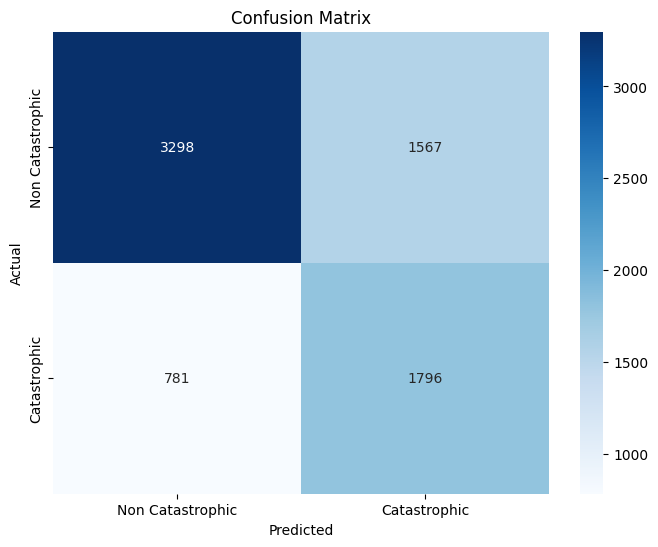

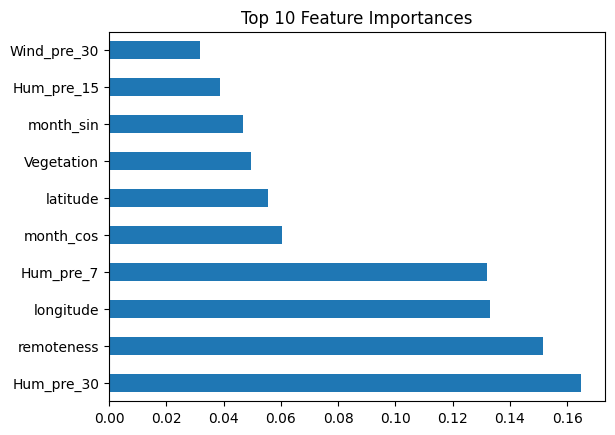

In [ ]:
# Plotting Confusion Matrix with labels
class_names = ['Non Catastrophic','Catastrophic']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
feature_importances_final = pd.Series(xgb_model_final.feature_importances_, index=X_train.columns)
feature_importances_final.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

### Exporting the Models

In [ ]:
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "models"))

joblib.dump(xgb_model_final, os.path.join(models_dir, "XGBoost_model.joblib"))

['/Users/leonkriesmair/Repos/BigDataProject/models/XGBoost_model.joblib']